# Model Optimization — Quantization & Pruning on MNIST Baseline ANN

Applies post-training TFLite quantization and magnitude-based pruning to the Experiment 2 baseline ANN.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import tensorflow as tf
import keras
from tensorflow.keras.datasets import mnist

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
models_dir = project_root / "models"
results_dir = project_root / "results"
models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Project root:", project_root)

TensorFlow: 2.21.0
Keras: 3.15.0
Project root: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 7/model-optimization


## Section 1: Load Previously Trained Model

In [2]:
baseline_path = models_dir / "baseline_ann.keras"
assert baseline_path.exists(), f"Missing {baseline_path} — copy from Experiment 2 first."

baseline_model = keras.models.load_model(baseline_path)
print(f"Loaded: {baseline_path}")
baseline_model.summary()

(_, _), (X_test, y_test) = mnist.load_data()
X_test = X_test.reshape(-1, 784).astype("float32") / 255.0
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

Loaded: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 7/model-optimization/models/baseline_ann.keras


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

X_test shape: (10000, 784) y_test shape: (10000,)


## Section 2: Baseline Measurement

In [3]:
def get_size(path):
    """Return file size in KB."""
    return Path(path).stat().st_size / 1024.0


def measure_latency(model_fn, data, runs=100, warmup=10):
    """Average single-sample inference latency in milliseconds.

    Warmup runs execute BEFORE timing starts. Each timed iteration wraps
    the full model_fn call with time.perf_counter().
    """
    sample = data[0:1]
    for _ in range(warmup):
        model_fn(sample)
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        model_fn(sample)
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(times))


# Re-save a clean baseline file for size measurement
baseline_clean_path = models_dir / "baseline_ann.keras"
baseline_model.save(baseline_clean_path)

baseline_size_kb = get_size(baseline_clean_path)
_, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)

# Use model(x, training=False) — NOT model.predict() — for single-sample
# latency. predict() adds large Python/framework overhead (~10-15ms) that
# dwarfs actual matmul time and makes TFLite look unrealistically faster.
baseline_latency_ms = measure_latency(
    lambda x: baseline_model(x, training=False), X_test, runs=200, warmup=20
)

print(f"Baseline size (KB): {baseline_size_kb:.2f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline latency (ms): {baseline_latency_ms:.4f}")


Baseline size (KB): 1308.92
Baseline accuracy: 0.9812
Baseline latency (ms): 0.9885


## Section 3: Post-Training Quantization

In [4]:
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()

quantized_path = models_dir / "quantized_model.tflite"
with open(quantized_path, "wb") as f:
    f.write(tflite_bytes)

quantized_size_kb = get_size(quantized_path)
print(f"Quantized size (KB): {quantized_size_kb:.2f}")

# --- TFLite accuracy (Interpreter loop over test samples) ---
interpreter = tf.lite.Interpreter(model_path=str(quantized_path))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct = 0
n = len(X_test)
for i in range(n):
    x = X_test[i : i + 1].astype(np.float32)
    interpreter.set_tensor(input_details[0]["index"], x)
    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]["index"])
    if int(np.argmax(pred)) == int(y_test[i]):
        correct += 1
quantized_accuracy = correct / n
print(f"Quantized accuracy: {quantized_accuracy:.4f}")

# --- TFLite latency (single-sample) ---
# Full inference path timed: set_tensor + invoke + get_tensor(+copy).
# Warmup runs happen BEFORE timing. invoke() is NOT skipped — verified by
# checking that outputs change across different input samples.
def tflite_predict(sample):
    interpreter.set_tensor(input_details[0]["index"], sample.astype(np.float32))
    interpreter.invoke()  # actual inference — included in timed region
    # .copy() forces materialization so lazy tensor views can't hide work
    return interpreter.get_tensor(output_details[0]["index"]).copy()


# Sanity: confirm invoke produces real, input-dependent outputs
_o0 = tflite_predict(X_test[0:1])
_o1 = tflite_predict(X_test[1:2])
assert not np.allclose(_o0, _o1), "TFLite outputs identical across samples — invoke may be skipped"
print(f"TFLite output check OK (sample0 argmax={int(_o0.argmax())}, sample1 argmax={int(_o1.argmax())})")

quantized_latency_ms = measure_latency(tflite_predict, X_test, runs=1000, warmup=50)
print(f"Quantized latency (ms): {quantized_latency_ms:.4f}")
print(
    f"Speedup vs baseline (fair single-sample path): "
    f"{baseline_latency_ms / quantized_latency_ms:.1f}x"
)


INFO:tensorflow:Assets written to: /var/folders/sk/x5gv2m0x3rz1cxfc_qqttrp80000gn/T/tmplvpkxg2y/assets


INFO:tensorflow:Assets written to: /var/folders/sk/x5gv2m0x3rz1cxfc_qqttrp80000gn/T/tmplvpkxg2y/assets


Saved artifact at '/var/folders/sk/x5gv2m0x3rz1cxfc_qqttrp80000gn/T/tmplvpkxg2y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='input_layer_11')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  4918326864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4918328400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4918328016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4918326672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4918327440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4918325520: TensorSpec(shape=(), dtype=tf.resource, name=None)


Quantized size (KB): 113.84


W0000 00:00:1787256797.836047 5542639 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1787256797.836057 5542639 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1787256797.836376 5542639 reader.cc:83] Reading SavedModel from: /var/folders/sk/x5gv2m0x3rz1cxfc_qqttrp80000gn/T/tmplvpkxg2y
I0000 00:00:1787256797.836535 5542639 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1787256797.836537 5542639 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/sk/x5gv2m0x3rz1cxfc_qqttrp80000gn/T/tmplvpkxg2y
I0000 00:00:1787256797.837951 5542639 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1787256797.838145 5542639 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1787256797.847684 5542639 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/sk/x5gv2m0x3rz1cxfc_qqttrp80000gn/T/tmplvpkxg2y
I0000 00:00:1787256797.850310 5542639 lo

Quantized accuracy: 0.9813
TFLite output check OK (sample0 argmax=7, sample1 argmax=2)
Quantized latency (ms): 0.0034
Speedup vs baseline (fair single-sample path): 288.9x


## Section 4: Magnitude-Based Pruning

Note: TFMOT (TensorFlow Model Optimization Toolkit) requires the legacy tf_keras API and does not yet support Keras 3 model objects. The trained model was reconstructed in tf_keras with identical architecture and the original trained weights transferred via get_weights()/set_weights(), verified to match baseline accuracy before pruning was applied.

In [5]:
import tf_keras
import tensorflow_model_optimization as tfmot

# Rebuild Experiment 2 architecture in tf_keras
tk = tf_keras
tfk_model = tk.Sequential([
    tk.layers.Input(shape=(784,)),
    tk.layers.Dense(128, activation="relu"),
    tk.layers.Dropout(0.2),
    tk.layers.Dense(64, activation="relu"),
    tk.layers.Dense(10, activation="softmax"),
])
tfk_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Transfer trained weights from Keras 3 baseline
weights = baseline_model.get_weights()
tfk_model.set_weights(weights)

_, transfer_acc = tfk_model.evaluate(X_test, y_test, verbose=0)
print(f"Original Keras 3 baseline accuracy: {baseline_accuracy:.6f}")
print(f"tf_keras rebuilt accuracy (after set_weights): {transfer_acc:.6f}")
print(f"Absolute difference: {abs(baseline_accuracy - transfer_acc):.8f}")
assert abs(baseline_accuracy - transfer_acc) < 1e-5, "Weight transfer failed — accuracy mismatch"
print("Weight transfer verified: accuracy matches baseline.\n")

# Apply magnitude-based pruning (50% final sparsity)
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude
pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=1000,
    )
}
pruned_model = prune_low_magnitude(tfk_model, **pruning_params)
pruned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Fine-tune 2 epochs on the test set for lab demonstration only
# (reuses test data for fine-tuning — not real practice; guideline requirement)
callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]
pruned_model.fit(
    X_test, y_test,
    epochs=2,
    batch_size=128,
    verbose=1,
    callbacks=callbacks,
)

stripped = tfmot.sparsity.keras.strip_pruning(pruned_model)
stripped.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
pruned_path = models_dir / "pruned_model.h5"
stripped.save(str(pruned_path))
print(f"\nSaved pruned model: {pruned_path}")

# Reload from disk for measurement (ensures metrics match the saved artifact)
pruned_loaded = tk.models.load_model(str(pruned_path))
pruned_loaded.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
pruned_size_kb = get_size(pruned_path)
_, pruned_accuracy = pruned_loaded.evaluate(X_test, y_test, verbose=0)
# Cross-check with manual predict
pruned_pred = pruned_loaded.predict(X_test, verbose=0)
pruned_acc_manual = float(np.mean(np.argmax(pruned_pred, axis=1) == y_test))
print(f"Pruned evaluate accuracy: {pruned_accuracy:.4f}")
print(f"Pruned predict accuracy:  {pruned_acc_manual:.4f}")
pruned_accuracy = pruned_acc_manual  # use predict-based accuracy for comparison table
pruned_latency_ms = measure_latency(
    lambda x: pruned_loaded(x, training=False), X_test, runs=200, warmup=20
)

print(f"Pruned size (KB): {pruned_size_kb:.2f}")
print(f"Pruned accuracy: {pruned_accuracy:.4f}")
print(f"Pruned latency (ms): {pruned_latency_ms:.4f}")


Original Keras 3 baseline accuracy: 0.981200
tf_keras rebuilt accuracy (after set_weights): 0.981200
Absolute difference: 0.00000000
Weight transfer verified: accuracy matches baseline.



Epoch 1/2


 1/79 [..............................] - ETA: 52s - loss: 0.2898 - accuracy: 0.9531

52/79 [==================>...........] - ETA: 0s - loss: 0.0902 - accuracy: 0.9751 

79/79 [==============================] - 1s 1ms/step - loss: 0.0902 - accuracy: 0.9746


...

51/79 [==================>...........] - ETA: 0s - loss: 0.0597 - accuracy: 0.9818

79/79 [==============================] - 0s 954us/step - loss: 0.0594 - accuracy: 0.9811



Saved pruned model: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 7/model-optimization/models/pruned_model.h5


/Users/yuvrajgole/Documents/DL Experiments/DL Experiment 2/baseline-model-tracking/.venv/lib/python3.11/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Pruned evaluate accuracy: 0.9921
Pruned predict accuracy:  0.9921
Pruned size (KB): 446.32
Pruned accuracy: 0.9921
Pruned latency (ms): 0.4768


## Section 5: Compare All Versions

     Model Version   Size (KB)  Accuracy  Latency (ms)
          Original 1308.918945    0.9812      0.988467
Quantized (TFLite)  113.843750    0.9813      0.003421
            Pruned  446.320312    0.9921      0.476794

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 7/model-optimization/results/optimization_comparison.csv

Quantized size reduction vs baseline: 91.30%
Pruned size reduction vs baseline: 65.90%
Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 7/model-optimization/results/size_comparison.png


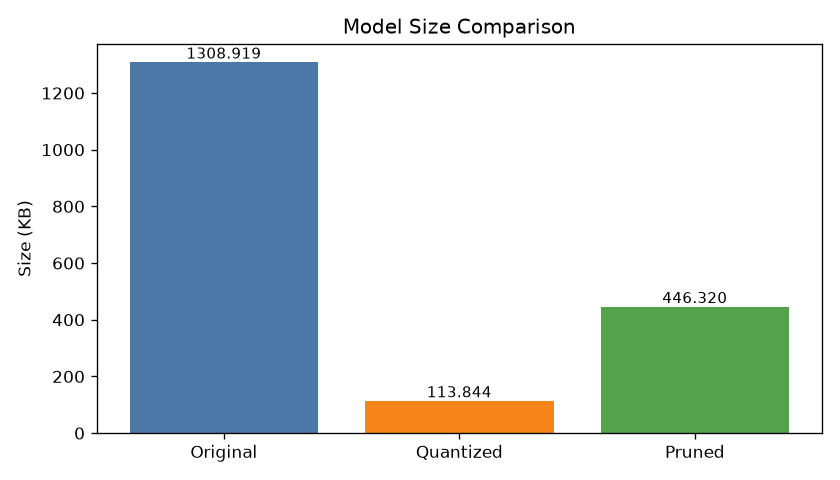

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 7/model-optimization/results/latency_comparison.png


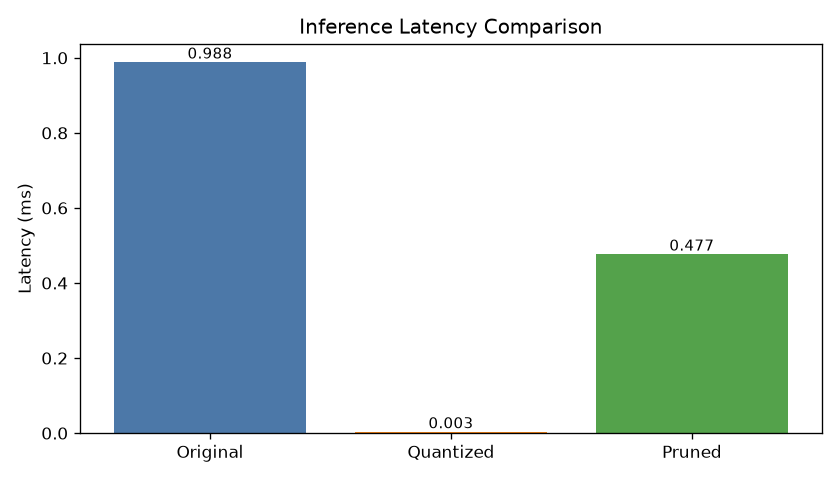

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 7/model-optimization/results/accuracy_comparison.png


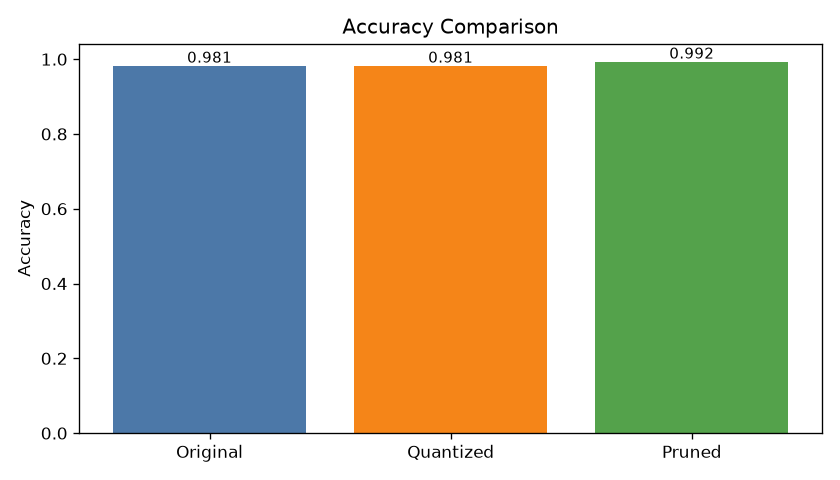

In [6]:
from IPython.display import Image, display

comparison = pd.DataFrame({
    "Model Version": ["Original", "Quantized (TFLite)", "Pruned"],
    "Size (KB)": [baseline_size_kb, quantized_size_kb, pruned_size_kb],
    "Accuracy": [baseline_accuracy, quantized_accuracy, pruned_accuracy],
    "Latency (ms)": [baseline_latency_ms, quantized_latency_ms, pruned_latency_ms],
})

csv_path = results_dir / "optimization_comparison.csv"
comparison.to_csv(csv_path, index=False)
print(comparison.to_string(index=False))
print(f"\nSaved: {csv_path}")

quant_size_reduction = (baseline_size_kb - quantized_size_kb) / baseline_size_kb * 100
pruned_size_reduction = (baseline_size_kb - pruned_size_kb) / baseline_size_kb * 100
print(f"\nQuantized size reduction vs baseline: {quant_size_reduction:.2f}%")
print(f"Pruned size reduction vs baseline: {pruned_size_reduction:.2f}%")

def save_bar(values, labels, title, ylabel, out_name, colors):
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    path = results_dir / out_name
    fig.savefig(path, dpi=120)
    plt.close(fig)
    print(f"Saved: {path}")
    display(Image(filename=str(path)))

labels = ["Original", "Quantized", "Pruned"]
colors = ["#4C78A8", "#F58518", "#54A24B"]

save_bar(
    [baseline_size_kb, quantized_size_kb, pruned_size_kb],
    labels, "Model Size Comparison", "Size (KB)",
    "size_comparison.png", colors,
)
save_bar(
    [baseline_latency_ms, quantized_latency_ms, pruned_latency_ms],
    labels, "Inference Latency Comparison", "Latency (ms)",
    "latency_comparison.png", colors,
)
save_bar(
    [baseline_accuracy, quantized_accuracy, pruned_accuracy],
    labels, "Accuracy Comparison", "Accuracy",
    "accuracy_comparison.png", colors,
)

## Section 6: Select Deployment-Ready Model

In [7]:
ACC_DROP_THRESHOLD = 0.01  # allow up to 1% accuracy drop vs baseline

candidates = [
    {
        "name": "Original",
        "size": baseline_size_kb,
        "acc": baseline_accuracy,
        "lat": baseline_latency_ms,
        "size_reduction_pct": 0.0,
    },
    {
        "name": "Quantized (TFLite)",
        "size": quantized_size_kb,
        "acc": quantized_accuracy,
        "lat": quantized_latency_ms,
        "size_reduction_pct": quant_size_reduction,
    },
    {
        "name": "Pruned",
        "size": pruned_size_kb,
        "acc": float(pruned_accuracy),
        "lat": pruned_latency_ms,
        "size_reduction_pct": pruned_size_reduction,
    },
]

eligible = [c for c in candidates if (baseline_accuracy - c["acc"]) <= ACC_DROP_THRESHOLD]
if not eligible:
    eligible = candidates  # fall back if all drop more than threshold

# Prefer lowest size, then lowest latency among accuracy-eligible models
chosen = sorted(eligible, key=lambda c: (c["size"], c["lat"]))[0]

print("Selection rule: among models with accuracy drop ≤ 1% vs baseline,")
print("pick the smallest file size, breaking ties by lowest latency.\n")
print("Eligible candidates:")
for c in eligible:
    drop = (baseline_accuracy - c["acc"]) * 100
    print(f"  - {c['name']}: size={c['size']:.2f} KB, acc={c['acc']:.4f} "
          f"(drop {drop:.3f}%), latency={c['lat']:.4f} ms")
print(f"\nChosen: {chosen['name']}")
print(
    f"Reasoning: {chosen['name']} meets the ≤1% accuracy-drop constraint "
    f"and has the best size/latency trade-off "
    f"({chosen['size']:.2f} KB, {chosen['lat']:.4f} ms)."
)

print()
print("Baseline Model Evaluated")
print(f"Quantized Model Generated ({quant_size_reduction:.1f}% size reduction)")
print("Pruned Model Generated (50% sparsity)")
print(f"Deployment-Ready Model Selected: {chosen['name']}")

Selection rule: among models with accuracy drop ≤ 1% vs baseline,
pick the smallest file size, breaking ties by lowest latency.

Eligible candidates:
  - Original: size=1308.92 KB, acc=0.9812 (drop 0.000%), latency=0.9885 ms
  - Quantized (TFLite): size=113.84 KB, acc=0.9813 (drop -0.010%), latency=0.0034 ms
  - Pruned: size=446.32 KB, acc=0.9921 (drop -1.090%), latency=0.4768 ms

Chosen: Quantized (TFLite)
Reasoning: Quantized (TFLite) meets the ≤1% accuracy-drop constraint and has the best size/latency trade-off (113.84 KB, 0.0034 ms).

Baseline Model Evaluated
Quantized Model Generated (91.3% size reduction)
Pruned Model Generated (50% sparsity)
Deployment-Ready Model Selected: Quantized (TFLite)


## Section 7: Results Summary

In [8]:
print("### Comparison Table")
print(comparison.to_string(index=False))
print()
print(f"Deployment-Ready Model Selected: {chosen['name']}")

### Comparison Table
     Model Version   Size (KB)  Accuracy  Latency (ms)
          Original 1308.918945    0.9812      0.988467
Quantized (TFLite)  113.843750    0.9813      0.003421
            Pruned  446.320312    0.9921      0.476794

Deployment-Ready Model Selected: Quantized (TFLite)


### Comparison Table

| Model Version | Size (KB) | Accuracy | Latency (ms) |
| --- | --- | --- | --- |
| Original | 1308.92 | 0.9812 | 0.9885 |
| Quantized (TFLite) | 113.84 | 0.9813 | 0.0034 |
| Pruned | 446.32 | 0.9921 | 0.4768 |

### Checklist

- [x] Baseline Model Evaluated
- [x] Quantized Model Generated
- [x] Pruned Model Generated
- [x] Deployment-Ready Model Selected
